[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ciri/iese-dsfb/blob/main/notebooks/400-Airline-Text-Analytics.ipynb)

# Airline Text Analytics

Airline companies are in fierce competition. One key dimension of competition is customer service, a direct driver of customer satisfaction.

![Alliances](https://raw.githubusercontent.com/ciri/iese-dsfb-mim/main/resources/text/airline-alliances.png)

As part of an effort to better understand passenger satisfaction within the Star Alliance network, we analyze customer reviews from thousands of airline passengers. The goal is to identify how factors like sentiment, seat type, travel purpose, and specific routes relate to overall recommendation rates.

The dataset includes 23,000+ reviews, with key variables such as:

- `Airline Name`: the name of the airline.
- `Route`: the flight route taken by the passenger.
- `Review`: free-text review written by the traveler.
- `Type Of Traveller`: e.g., Solo Leisure, Business, Couple.
- `Recommended`: whether the traveler recommends the airline (yes/no).
- `Seat Type`: seat class (e.g., Economy, Business).

Data Source: [Airlinequality.com](https://www.airlinequality.com/) via [Kaggle](https://www.kaggle.com/datasets/khushipitroda/airline-reviews/data)

**Required packages** — run once before starting:

```bash
pip install pandas matplotlib seaborn nltk tqdm wordcloud transformers torch google-genai
# or with conda:
# conda install pandas matplotlib seaborn nltk tqdm && pip install wordcloud transformers torch google-genai
```

## Part I: Working with Text Data

### Strings

Text data always starts out in the form of a string. A **string** is a sequence (list) of **characters**. This includes the (English) alphanumeric characters and also special characters like white space, punctuation, etc. Other symbols, like emoticons, can also appear in your data, specially in social networks data. Besides that, you can also find letters from other languages (Spanish, Portuguese, etc) or alphabets (Cyrillic, hiragana, etc), and even ideographs (such as Han characters).


### Characters as numbers

There is a basic set of 127 characters, called the **ASCII characters**, which are encoded in the same way by all the computers, so you will never have trouble with them. They include the English letters (without accents), the numbers, basic punctuation (not curly quote marks or long dashes), white space, **control characters** such as the new line, represented in programming languages as `\n`, and other symbols familiar to you, such as the dollar ($) and the hash (#) symbols. The complete list can be easily found in Internet.

Non-ASCII characters can be encoded by different computers or different text editors in different ways. Mind that, if you capture string data on your own, you will probably find some of these characters in your data. Even when the documents are expected to be in English, they can be contaminated by other languages: Han
characters, German dieresis, Spanish eñe, etc. 

The preferred **encoding** is **UTF-8 (utf-8)**, which is the default encoding in Macintosh computers. Reading and writing text files in Pandas, the argument encoding allows you to manage both UTF-8 and the alternative encoding **Latin-1 (latin1)**. Windows computers use their own system, which is region specific. In US and Western Europe, this is **Windows-1252**, which is very close to Latin-1, though not exactly the same.

In [ ]:
'A' == 'a'
#65 == 97

False

In [22]:
iese = "IESE Business School"

splitted = iese.split(' ')

splitted

'-----'.join(splitted)

'IESE-----Business-----School'

### Strings as lists

Both lists and strings are **sequences**, so they share some core behaviours. A string can be thought of as a list of characters. You can use `len()` and slicing just like a list:

In [65]:
school = 'IESE Business School'
print(len(school))
print(school[:4])    # first 4 characters
print(school[-6:])   # last 6 characters

20
IESE
School



### Python string methods

Python has a rich set of methods for manipulating strings:

| Method | What it does |
|---|---|
| `lower()` / `upper()` | Change case |
| `replace(old, new)` | Find and replace |
| `split(sep)` | Split into a list of parts |
| `join(list)` | Join a list back into a string |
| `count(pattern)` | Count occurrences |

In [66]:
name = 'Enric Junque de Fortuny'

print(name.upper())
print(name.lower())
print(name.split(' '))
print('---'.join(name.split(' ')))

ENRIC JUNQUE DE FORTUNY
enric junque de fortuny
['Enric', 'Junque', 'de', 'Fortuny']
Enric---Junque---de---Fortuny


## Airline Reviews Dataset

Let's load the data. I've already partially cleaned it up for you (no duplicates). You can download it from [here](https://raw.githubusercontent.com/ciri/iese-dsfb/refs/heads/main/resources/text/Airline_Reviews.csv).

In [34]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

## Use your local copy:
df = pd.read_csv('../resources/text/Airline_Reviews_v2.csv')[['Airline Name','From','To','Via','Review','Type Of Traveller','Recommended','Seat Type']]

## Or download every time:
# df = pd.read_csv('https://raw.githubusercontent.com/ciri/iese-dsfb-mim/refs/heads/main/resources/text/Airline_Reviews_v2.csv')[['Airline Name','From','To','Via','Review','Type Of Traveller','Recommended','Seat Type']]

df

,Airline Name,From,To,Via,Review,Type Of Traveller,Recommended,Seat Type
0,AB Aviation,Moroni,Moheli,NaN,"Moroni to Moheli. Turned out to be a pretty decent airline. Online booking worked well, checkin and boarding was fine and the plane looked well maintained. Its a very short flight - just 20 minutes or so so i didn't expect much but they still managed to hand our a bottle of water and some biscuits which i though was very nice. Both flights on time.",Solo Leisure,1,Economy Class
1,AB Aviation,Moroni,Anjouan,NaN,"Moroni to Anjouan. It is a very small airline. My ticket advised me to turn up at 0800hrs which I did. There was confusion at this small airport. I was then directed to the office of AB Aviation which was still closed. It opened at 0900hrs and I was told that the flight had been put back to 1300hrs and that they had tried to contact me. This could not be true as they did not have my phone number. I was with a local guide and he had not been informed either. I presume that I was bumped off. The later flight did operate but as usual, there was confusion at check-in. The flight was only 30mins and there were no further problems. Not a good airline but it is the only one for Comoros.",Solo Leisure,0,Economy Class
2,AB Aviation,Anjouan,Dzaoudzi,NaN,"Anjouan to Dzaoudzi. A very small airline and the only airline based in Comoros. Check-in was disorganised because of locals with big packages and disinterested staff. The flight was fortunately short (30 mins). Took off on time and landed on time. With a short flight like there was of course no in-flight entertainment nor cabin service except for biscuits and a bottle of water, which was quite nice!",Solo Leisure,0,Economy Class
3,Adria Airways,Frankfurt,Pristina,NaN,"Please do a favor yourself and do not fly with Adria. On the route from Munich to Pristina in July 2019 they lost my luggage and for 10 days in a row, despite numerous phone calls they were not able to locate it. 11 days later the luggage arrived at the destination completely ruined. Applying for compensation, they ignored my request. Foolishly again, I booked another flight with them (345 euros) Frankfurt - Pristina in September 2019. They cancelled the flight with no reason 24 hours before the departure. Desperate phone calls to customer service to get anything (rerouting, compensation, etc) were not responded. I will never fly again with Adria. What a disgrace! Shame on you Adria for constantly deceiving your customers.",Solo Leisure,0,Economy Class
4,Adria Airways,Sofia,Amsterdam,Ljubljana,"Do not book a flight with this airline! My friend and I should have returned from Sofia to Amsterdam on September 22 and 3 days before, they sent us an SMS informing the flight was cancelled. For 3 straight days we tried to reach the airline and the web agent (e-dreams) and we did not get a solution. Finally, 18 hours before our cancelled flight time, and after 35 minutes on a call (waiting), the airline was able to get us on a flight with Lufthansa. Do not book Adria Airways, it is unreliable and in our case, it ruined our last days of holidays since we needed to be on the phones all day.",Couple Leisure,0,Economy Class
...,...,...,...,...,...,...,...,...
23041,ZIPAIR,Bangkok,Tokyo,NaN,"Bangkok to Tokyo. I’ve flown many low cost airlines before, but they still served meals, offered beverages, and just had more general information. The flight attendants were there for no reason because they don’t even go down the aisle once even for water. There’s less than ten movies to choose from for a 8 hr flight. The customer service is absolutely terrible, not even a phone number on their website, and they never got back to any emails. On our way home from Thailand, we were denied boarding because they couldn’t complete the transfer due to the check in counter because outside the terminal in Japan. We couldn’t make our flight and had to buy another flight with a completely different airline. Lost over 1000$ due to this discrepancy 

### Exploring the dataset

There is not much to `describe()` here since most columns are text. Let's use `.value_counts()` to count categories, and `.groupby()` to aggregate.

In [68]:
df['Seat Type'].value_counts()

Seat Type
Economy Class      19129
Business Class      2097
Premium Economy      646
First Class          186
Name: count, dtype: int64

In [ ]:
df.groupby('Seat Type').count()

,Airline Name,From,To,Via,Review,Type Of Traveller,Recommended
Seat Type,,,,,,,
Business Class,2097,1806,1805,517,2097,1808,2097
Economy Class,19129,16747,16731,3533,19129,16829,19129
First Class,186,168,168,23,186,168,186
Premium Economy,646,608,605,145,646,613,646


In [71]:
df.groupby('Seat Type').nunique()

,Airline Name,From,To,Via,Review,Type Of Traveller,Recommended
Seat Type,,,,,,,
Business Class,217,436,471,175,2097,4,2
Economy Class,489,2025,2271,677,19129,4,2
First Class,75,103,106,19,186,4,2
Premium Economy,157,240,260,83,646,4,2


**You try it**

What's the most common route? 

Hint: use From and To, you can combine them using `df.From` + `df.To`.

### Exploring the review text

When a Pandas column contains string, we can access its **string methods**. Pandas string methods are vectorized versions of the above methods. They return a series of the same length, in which each term results from applying a string function to the corresponding term of `s`. The syntax of these functions is typically `s.str.fname(args)`, where `s` is a Pandas series of strings (or a list of strings) and args is a set of ad hoc arguments.

For example, `.str.contains("pattern")` returns a Boolean series — True wherever the pattern appears:

In [ ]:
f_has_space = df.Review.str.lower().str.contains("space")
df[f_has_space].head(3)

In [75]:
# Let's read one full review
print(df.loc[41].Review)

Excellent flights both ways with Adria Airways from Manchester to Ljubljana. Staff friendly but unobtrusive. Leg room far better than most economy flights, seats comfy and plenty of storage space. Flights on time, quick and efficient boarding and disembarking, smooth take offs and landings. All in all a very pleasant experience.


**You try it**

1. Use `str.contains` to find the number of reviews which mention the following keywords: `'Crew'`, `'Bag'`, `'Passenger'`.
2. Calculate the total count across all 3 keywords.
3. Does review 186 from Aegean Airlines contain the word crew?

Hint: don't forget `.lower()`!

### Topic Detection: Frequent Word Analysis

Advanced techniques like topic modeling (LDA) or transformer-based classification exist, but a simple and quick method is **word frequency analysis**. It gives a fast sense of recurring topics — service, food, delays, seats — without any machine learning.

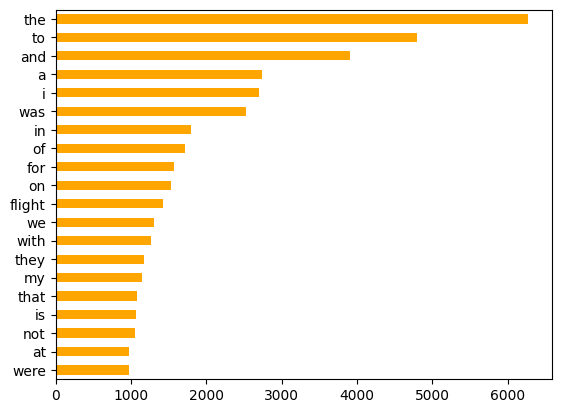

In [76]:
sample = df.sample(1000, random_state=42)
all_words = sample.Review.str.lower().str.split().sum()

pd.Series(all_words).value_counts().head(20)[::-1].plot.barh(color='orange');

The top terms are mostly **stopwords** — words that carry no meaning (the, a, I, was ...). We can filter them out using a standard list from NLTK:

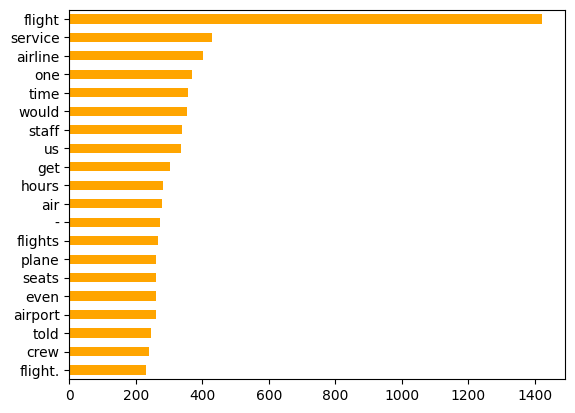

In [77]:
#! pip install nltk
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop = set(stopwords.words('english'))

filtered_words = [w for w in all_words if w not in stop]
pd.Series(filtered_words).value_counts().head(20)[::-1].plot.barh(color='orange');

Let's try to plot this as a wordcloud. The beauty and power of python is that - regardless of your objective - you can always find some package that will get close to what you want:

<center>
    <img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/images/xkcdimport.png' width='50%'>
</center>

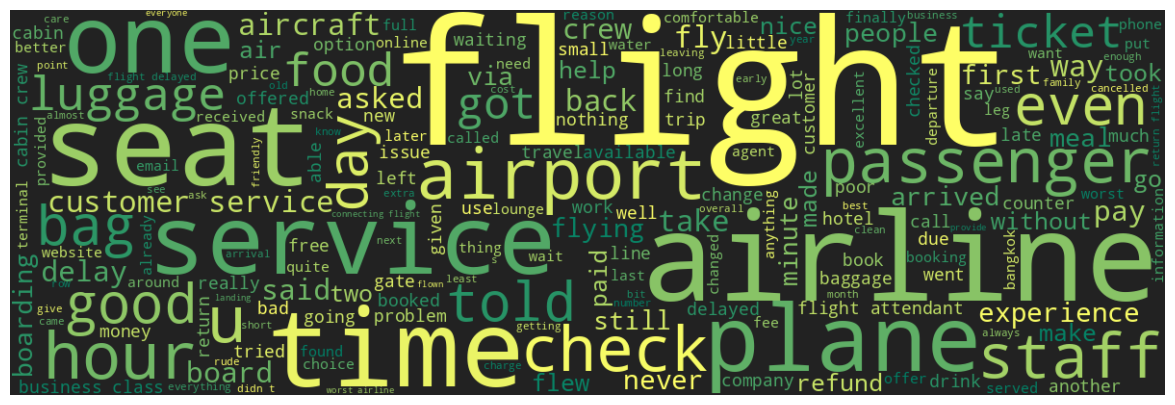

In [78]:
#! pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(filtered_words)
wordcloud = WordCloud(width=1200, height=400, background_color='#222222', colormap='summer').generate(text)

plt.figure(figsize=(15, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

---
## Part II: Sentiment Analysis

Word frequency tells us **what** passengers write about. But it treats every word in isolation and can't distinguish *"good food"* from *"not good food"*, or *"no delays"* from *"constant delays"*. Is looking at individual words really enough?

Star Alliance carries ~762 million passengers per year across 25 member airlines. Yet in 23,046 verified reviews from Airlinequality.com:

| Segment | Do not recommend | Recommend |
|---|---|---|
| **Star Alliance** | **70%** | 30% |
| All airlines in dataset | 66% | 34% |

**Governing question:** Why do Star Alliance passengers not recommend their airline?

<svg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 820 300' font-family='Arial,sans-serif'>

  <!-- Connectors first so boxes sit on top -->
  <line x1='196' y1='150' x2='228' y2='150' stroke='#7F7F7F' stroke-width='1.5'/>
  <line x1='228' y1='50'  x2='228' y2='250' stroke='#7F7F7F' stroke-width='1.5'/>
  <line x1='228' y1='50'  x2='350' y2='50'  stroke='#7F7F7F' stroke-width='1.5'/>
  <line x1='228' y1='150' x2='350' y2='150' stroke='#7F7F7F' stroke-width='1.5'/>
  <line x1='228' y1='250' x2='350' y2='250' stroke='#7F7F7F' stroke-width='1.5'/>

  <!-- Root -->
  <rect x='8' y='110' width='188' height='80' rx='3' fill='#002060'/>
  <text x='102' y='138' text-anchor='middle' fill='white'   font-size='12' font-weight='bold'>Why do passengers</text>
  <text x='102' y='156' text-anchor='middle' fill='white'   font-size='12' font-weight='bold'>not recommend?</text>
  <text x='102' y='176' text-anchor='middle' fill='#7BAFD4' font-size='10'>Star Alliance: 70% don't recommend</text>

  <!-- Leaf 1: Hard product -->
  <rect x='350' y='18' width='190' height='64' rx='3' fill='#DAE3F3' stroke='#1F5C99' stroke-width='1'/>
  <text x='445' y='40' text-anchor='middle' fill='#002060' font-size='12' font-weight='bold'>Hard product</text>
  <text x='445' y='58' text-anchor='middle' fill='#1F5C99' font-size='10'>Cabin · Seat · IFE</text>
  <text x='554' y='50' text-anchor='start'  fill='#595959' font-size='10'>→ Measurable via structured ratings</text>

  <!-- Leaf 2: Soft product (highlighted) -->
  <rect x='350' y='118' width='190' height='64' rx='3' fill='#1F5C99' stroke='#002060' stroke-width='2'/>
  <text x='445' y='140' text-anchor='middle' fill='white'   font-size='12' font-weight='bold'>Soft product</text>
  <text x='445' y='158' text-anchor='middle' fill='#BDD4ED' font-size='10'>Crew · Food · Beverage</text>
  <text x='554' y='142' text-anchor='start'  fill='#595959' font-size='10'>→ Lives in free-text reviews</text>
  <text x='554' y='158' text-anchor='start'  fill='#595959' font-size='10'>★ Focus of this session</text>

  <!-- Leaf 3: Operations -->
  <rect x='350' y='218' width='190' height='64' rx='3' fill='#DAE3F3' stroke='#1F5C99' stroke-width='1'/>
  <text x='445' y='240' text-anchor='middle' fill='#002060' font-size='12' font-weight='bold'>Operational performance</text>
  <text x='445' y='258' text-anchor='middle' fill='#1F5C99' font-size='10'>Punctuality · Baggage · Reliability</text>
  <text x='554' y='250' text-anchor='start'  fill='#595959' font-size='10'>→ Measurable via OTP and delay records</text>

</svg>

For that we now turn to **sentiment analysis**: a natural language processing (NLP) technique used to identify and quantify emotions in text. It is a staple of marketing analytics, as it helps companies understand how customers feel about their brand, products, or services by analyzing reviews, social media, and survey responses. 

Today, let us try to see if we can discover any postive or negative trends in the flight experience.

We'll go through three approaches, each more powerful (and discovered later):

| Approach | Method | Speed | Accuracy |
|---|---|---|---|
| 1. Ad-hoc | Keyword matching | Instant | Low |
| 2. Lexicon-based | VADER dictionary | Fast | Medium |
| 3. Machine Learning | Transformer model | Slower | High |

In [5]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

## Use your local copy:
df = pd.read_csv('../resources/text/Airline_Reviews_v2.csv')[['Airline Name','From','To','Via','Review','Type Of Traveller','Recommended','Seat Type']]

## Or download every time:
# df = pd.read_csv('https://raw.githubusercontent.com/ciri/iese-dsfb-mim/refs/heads/main/resources/text/Airline_Reviews_v2.csv')[['Airline Name','From','To','Via','Review','Type Of Traveller','Recommended','Seat Type']]


### Approach 1: Ad-hoc (Keyword Matching)

The simplest method: check if positive or negative words appear in the review.

In [6]:
good = df.Review.str.lower().str.contains('good')
bad  = df.Review.str.lower().str.contains('bad')

print(f"Reviews containing 'good': {good.mean():.1%}")
print(f"Reviews containing 'bad':  {bad.mean():.1%}")

Reviews containing 'good': 21.6%
Reviews containing 'bad':  9.8%


**You try it**

Implement the sentiment scoring function. Define the sentiment of review $i$ as:
$$S_i = G_i - B_i$$
where $G_i = 1$ if "good" appears, $B_i = 1$ if "bad" appears.

Plot the distribution of sentiment scores as a histogram.

Here is an alternative way to write this using `.apply()`, which applies a function row-by-row. This pattern becomes essential for more complex scoring later:

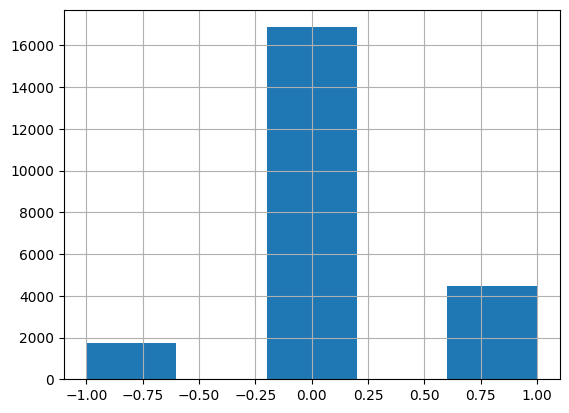

In [7]:
def sentiment(review):
    is_good = 'good' in review.lower()
    is_bad  = 'bad'  in review.lower()
    return is_good - is_bad

df['simple_sentiment'] = df.Review.apply(sentiment)
df.simple_sentiment.hist(bins=5);

**Litmus test**

This all feels a bit ad-hoc and we should probably validate this with the recommendations to make sure the sentiment makes sense ... Does our simple sentiment score actually correlate with whether passengers recommend the airline?

In [8]:
df[['simple_sentiment','Recommended']].corr()

,simple_sentiment,Recommended
simple_sentiment,1.000000,0.319901
Recommended,0.319901,1.000000


### Approach 2: Lexicon-Based (VADER)

The **VADER** (Valence Aware Dictionary and sEntiment Reasoner) lexicon was developed by Hutto & Gilbert (2014) at Georgia Tech. They had human annotators rate thousands of words for sentiment intensity, then built a dictionary capturing both polarity (positive/negative) and strength. It handles informal text, punctuation emphasis (!), and capitalization well.

In [9]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

In [10]:
# Peek at the lexicon — each word has a valence score
print(sia.lexicon.get("good"))

1.9


In [11]:
# polarity_scores returns neg/neu/pos/compound — compound is the overall score (-1 to +1)
sia.polarity_scores('I really loved the snacks on the flight!')

{'neg': 0.0, 'neu': 0.572, 'pos': 0.428, 'compound': 0.6689}

In [12]:
from tqdm import tqdm
tqdm.pandas()

def get_sentiment(review):
    return sia.polarity_scores(review)['compound']

df['sentiment'] = df['Review'].progress_apply(get_sentiment)

100%|██████████| 23046/23046 [00:13<00:00, 1738.98it/s]


**You try it**

1. Show the 2 most positive and 2 most negative reviews according to VADER.
2. Run the correlation test: does VADER sentiment correlate better with `Recommended` than the ad-hoc approach?

Hint: use `df.sort_values()`

### Approach 3: Machine Learning

A popular family of machine learning approaches to sentiment analysis is BERT (Bidirectional Encoder Representations from Transformers). Once you know how to use them, they become the swiss army knife of text analytics. BERT models have been fine-tuned for tasks like:
* Sentiment analysis
* Text classification
* Topic detection
* ...

For now, let's keep it simple with a lightweight version of BERT, already fine-tuned for sentiment:
`distilbert-base-uncased-finetuned-sst-2-english`. It's fast, free to use, and good enough to show the power of transformer models over rule-based methods.

Note: this may not run on all computers, if it doesn't on yours, switch to google collab.

In [13]:
#! pip install transformers torch
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

def scored_sentiment(text):
    result = sentiment_model(text)[0]
    return result['score'] if result['label'] == 'POSITIVE' else -result['score']

# Quick demo
print(scored_sentiment('Best. Flight. Ever.'))
print(scored_sentiment('Worst experience of my life. Never again.'))

/home/enric/Teaching/DSfB/iese-dsfb/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7400.88it/s]


0.9998503923416138
-0.9997391104698181


**You try it**

Use the `.progress_apply` function to apply sentiment scoring to all BERT sentiments.

**Going further: emotion detection**

Binary positive/negative is useful but coarse. The model below - trained by your professor ;-) on the [GoEmotions dataset](https://huggingface.co/datasets/google-research-datasets/go_emotions) - classifies text into 28 fine-grained emotions (joy, anger, disappointment, admiration ...). It's based on ModernBERT, a post-ChatGPT architecture, and available on [HuggingFace](https://huggingface.co/cirimus/modernbert-base-go-emotions).

In [14]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model           = "cirimus/modernbert-base-go-emotions",
    top_k           = 5
)

text = "The crew was stellar but my why mist my seat be so incredibly uncomfortable for a 12-hour flight."
predictions = classifier(text)

top_5 = sorted(predictions[0], key = lambda x: x["score"], reverse = True)[:5]
print("Top 5 emotions detected:")
for pred in top_5:
    print(f"  {pred['label']:15s}: {pred['score']:.3f}")

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 10426.26it/s]


Top 5 emotions detected:
  admiration     : 0.641
  disappointment : 0.271
  annoyance      : 0.096
  neutral        : 0.079
  disapproval    : 0.055


### Who Are the Stars in Star Alliance?

Now that we have sentiment scores, let's rank airlines. We'll filter to Star Alliance members for a focused comparison.

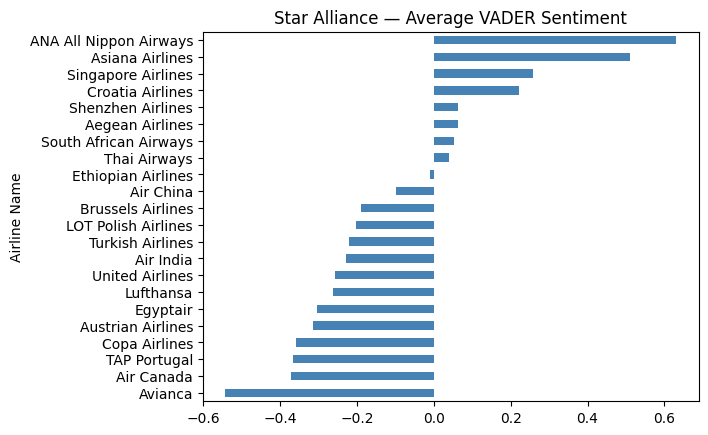

In [15]:
star_alliance_members = [
    'Aegean Airlines','Air Canada','Air China','Air India',
    'ANA All Nippon Airways','Asiana Airlines','Austrian Airlines',
    'Avianca','Brussels Airlines','Copa Airlines','Croatia Airlines',
    'Egyptair','Ethiopian Airlines','Eva Air','LOT Polish Airlines',
    'Lufthansa','Scandinavian Airlines','Shenzhen Airlines',
    'Singapore Airlines','South African Airways',
    'Swiss International Air Lines','TAP Portugal',
    'Thai Airways','Turkish Airlines','United Airlines'
]

f_star = df['Airline Name'].isin(star_alliance_members)
df[f_star].groupby('Airline Name')['sentiment'].mean().sort_values().plot.barh(
    color='steelblue', title='Star Alliance — Average VADER Sentiment'
);

> What follow-up analysis would you do if you worked at Star Alliance?

---
## Part III: Aspect-Based Analysis with LLMs

Overall sentiment tells you whether a review is positive or negative. But an airline category manager needs sharper answers: *How is the crew rated? What do passengers say about luggage? How does food score on long-haul routes?*

This is **aspect-based sentiment analysis** — and it's where LLMs shine. Rather than training a separate model for each aspect (crew, food, luggage, punctuality ...), you just change the prompt.

You have two options for any custom NLP task:
1. Fine-tune your own model (requires labelled data — take the ML class)
2. **Use an LLM to annotate your data** — powerful, fast, and requires no training data

Let's try the second with Google Gemini.

**Setup:**
1. Create a [Google account](https://accounts.google.com/) or log in.
2. Create a free [Gemini API key](https://aistudio.google.com/app/apikey).
3. Install the SDK: `pip install -q -U google-genai`

In [57]:
API_KEY = '...'  # paste your key here

In [58]:
# ! pip install -q -U google-genai
from google import genai

client = genai.Client(api_key=API_KEY)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Explain in one number what the meaning of life is."
)
print(response.text)

**42**

(As calculated by the supercomputer Deep Thought in Douglas Adams's *The Hitchhiker's Guide to the Galaxy*, for "the Ultimate Question of Life, the Universe, and Everything.")


### Scoring an aspect: crew

We'll start by scoring the **crew** aspect — one of the most frequently mentioned in airline reviews. The key idea: write a prompt that extracts a structured score from free text. First test your prompt manually in your favourite LLM chat interface, then automate it below.

In [59]:
df_ana = df[df['Airline Name'] == 'ANA All Nippon Airways']
df_ana[['Airline Name','Review']].head()

,Airline Name,Review
4350,ANA All Nippon Airways,"Pretty disappointed with ANA, especially when compared to JAL. Seats are dated and half are very exposed. The Japanese food was generally good and at times excellent. The champagne was undrinkable. The pre-flight drinks (where offered) were from plastic disposable cups. The main listed wine selection on every leg was unavailable. The crew were generally good and attentive. It is such a pity that they appear to be economising."
4351,ANA All Nippon Airways,"Great service, lovely crew, comfortable seats, lots of leg room ( I am 6'2""), roomy toilets and an immaculately clean aircraft. It’s hard to imagine how a 14 hour flight in economy could be done any better. I paid in advance an extra £15 for a special Japanese meal which was most definitely worth it and really delicious, beautifully presented."
4352,ANA All Nippon Airways,"Overall was a good experience, check in went smoothly, food was decent for airline food and the staff was friendly. The main downside was that the lounge in Tokyo Haneda was overcrowded."
4353,ANA All Nippon Airways,Paid for seats so entire family is together. Airline changes aircraft/seats and puts a stranger between us. Not even a single thought goes in this process. Extremely difficult to connect with someone on the phone. Unfortunately the competition is worse. Over the years flying changed from a fun way to travel to a dreadful experience.
4354,ANA All Nippon Airways,"I’m super unhappy about ANA service. They asked me and my daughter to move our luggage after we have settled down, me and my daughter are both short, but she didn’t offer her help, so that I almost dropped my luggage on one of passengers. Later during the breakfast time, she didn’t offer food to my daughter until I figured it out. My daughter is shy girl, so I had to step out and ask her to bring the breakfast to her. This kind of things have never happened to me before. I’m extremely unhappy about ANA service."


In [61]:
PROMPT = """
You're a world-class customer service analyst who is analyzing airline reviews.
Score the crew on the flight (friendliness, professionalism, helpfulness) from 0 to 10.
If crew is not mentioned, return 'N/A'.

Also extract the most relevant passage that supports your score.

Format your response as:

<score>YOUR_SCORE_HERE</score><passage>YOUR_PASSAGE_HERE</passage>

Important: only reply with the required tags and scores. Don't add anything else.
"""

def score_crew(review_text):
    prompt = PROMPT + "\nReview:" + review_text
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )
    return response.text.strip()

score_crew('the crew was amazing. the food was good too.')

'<score>10</score><passage>the crew was amazing.</passage>'

**You try it**

1. Apply `score_crew()` to `df_sample` below (25 rows - don't run on the full dataset yet, it uses API quota).
2. Parse the output: create a `CrewScore` column and a `Rationale` column.
3. **Bonus:** change the `PROMPT` to score a *different* aspect - luggage handling, food quality, or punctuality. How little do you need to change to pivot to a completely different analysis?

Hints:
- Use `.apply(score_crew)` or `.progress_apply(score_crew)` to get a column of raw LLM output strings.
- Use string splitting on `<score>` and `<passage>` tags to extract the values.
- LLMs sometimes don't follow instructions ... filter out rows where the tags are missing.

In [ ]:
df_sample = df.sample(25, random_state=42)
# llm_scores = df_sample['Review'].apply(score_crew)
# ...